# Setup

In [4]:
from pprint import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seed
seed = 42

# sklearn config
from sklearn import set_config
set_config(transform_output='pandas', display='text')

# 1. Train-Test Split

In [45]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(
    return_X_y=True,
    as_frame=True,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    stratify=y,
    random_state=seed,
)

display(y_train.value_counts() / len(y_train))
display(y_test.value_counts() / len(y_test))

target
0    0.333333
2    0.333333
1    0.333333
Name: count, dtype: float64

target
0    0.333333
2    0.333333
1    0.333333
Name: count, dtype: float64

# 2. Cross Validation

## 1) `cross_validate`

```python
def cross_validate(
    estimator: BaseEstimator,
    X: MatrixLike,
    y: MatrixLike | ArrayLike | None = None,
    *,
    groups: ArrayLike | None = None,    # for group-aware cv.
    scoring: ArrayLike | tuple | ((...) *->* Any) | Mapping | None = None,
    cv: int | BaseCrossValidator | Iterable | None = None,
    n_jobs: Int | None = None,
    verbose: Int = 0,
    params: dict | None = None,
    pre_dispatch: Int | str = "2\*n_jobs",
    return_train_score: bool = False,
    return_estimator: bool = False,
    return_indices: bool = False,
    error_score: Float | str = np.nan
) -> Any
```

In [25]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

# Data
X, y = load_iris(
    return_X_y=True,
    as_frame=True,
)

# Estimator
estimator = LogisticRegression()

# CV
cv = cross_validate(
    estimator=estimator,
    X=X_train,
    y=y_train,
    cv=2,
    scoring='accuracy',

    return_train_score=True,    # return train scores too.
    return_estimator=True,      # return estimators for each cv.
    return_indices=True,        # return sample indices for each cv.
    verbose=2,                  # verbose level, 0 ~ 2.
)

cv

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


{'fit_time': array([0.04169536, 0.01500082]),
 'score_time': array([0.00190616, 0.00162864]),
 'estimator': [LogisticRegression(), LogisticRegression()],
 'indices': {'train': (array([ 58,  59,  60,  62,  63,  65,  66,  67,  68,  69,  70,  71,  72,
           73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,
           86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,
           99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
          112, 113, 114, 115, 116, 117, 118, 119]),
   array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
          17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
          34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
          51, 52, 53, 54, 55, 56, 57, 61, 64])),
  'test': (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
          17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
          34, 35, 36, 37, 3

## 2) `cross_val_score`

- Only scores -> simpler version of `cross_validate`.

```python
def cross_val_score(
    estimator: BaseEstimator,
    X: MatrixLike,
    y: MatrixLike | ArrayLike | None = None,
    *,
    groups: ArrayLike | None = None,
    scoring: str | Callable | None = None,
    cv: int | BaseCrossValidator | Iterable | None = None,
    n_jobs: Int | None = None,
    verbose: Int = 0,
    params: dict | None = None,
    pre_dispatch: Int | str = "2*n_jobs",
    error_score: Float | Literal["raise"] = np.nan
) -> ndarray
```

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

# Data
X, y = load_iris(
    return_X_y=True,
    as_frame=True,
)

# Estimator
estimator = LogisticRegression()

# CV
cv_score = cross_val_score(
    estimator=estimator,
    X=X_train,
    y=y_train,
    cv=2,
    verbose=2,                  # verbose level, 0 ~ 2.
)

cv_score

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


array([0.95      , 0.98333333])

## 3) `cross_val_predict`

```python
def cross_val_predict(
    estimator: BaseEstimator,
    X: MatrixLike,
    y: MatrixLike | ArrayLike | None = None,
    *,
    groups: ArrayLike | None = None,
    cv: int | BaseCrossValidator | Iterable | None = None,
    n_jobs: Int | None = None,
    verbose: Int = 0,
    params: dict | None = None,
    pre_dispatch: Int | str = "2*n_jobs",
    method: Literal[    # method name of estimator that generates the prediction.
        "predict",
        "predict_proba",
        "predict_log_proba",
        "decision_function"
    ] = "predict"
) -> ndarray
```

In [30]:
from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LogisticRegression

# Data
X, y = load_iris(
    return_X_y=True,
    as_frame=True,
)

# Estimator
estimator = LogisticRegression()

# CV
cv_pred = cross_val_predict(
    estimator=estimator,
    X=X_train,
    y=y_train,
    cv=2,
    verbose=2,                  # verbose level, 0 ~ 2.
)

cv_pred

[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:    0.0s finished


array([0, 1, 1, 0, 1, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 0, 0, 2, 2, 0, 1, 0,
       2, 0, 1, 2, 2, 0, 2, 0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 2, 0, 1, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 1, 2, 1, 0, 2, 1, 2, 0, 2, 0, 1, 2, 0, 2, 1,
       2, 1, 1, 2, 0, 0, 0, 1, 1, 2, 1, 2, 2, 1, 0, 2, 1, 0, 2, 0, 2, 1,
       1, 0, 1, 2, 0, 0, 2, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 1, 1,
       0, 2, 1, 1, 0, 0, 0, 0, 1, 0])

# 3. Classification

## 1) Summary

### General

| Metric | Formula | API |
|---|---|---|
| Accuracy | $\mathrm{Accuracy}=\frac{TP+TN}{M}$ | `accuracy_score` |
| Precision | $P=\frac{TP}{TP+FP}$ | `precision_score` |
| Recall (Sensitivity) | $R=\frac{TP}{TP+FN}$ | `recall_score` |
| F1-score | $F_1=\frac{2PR}{P+R}=\frac{2TP}{2TP+FP+FN}$ | `f1_score` |
| ROC-AUC | $\mathrm{ROC\text{-}AUC}=\int_0^1 \mathrm{TPR}\,d(\mathrm{FPR})$<br>$\mathrm{TPR}=\frac{TP}{TP+FN}$<br>$\mathrm{FPR}=\frac{FP}{FP+TN}$ | `roc_auc_score` |
| PR-AUC | $\mathrm{PR\text{-}AUC}=\int_0^1 P(R)\,dR$ | `auc` |
| Average Precision (AP) | $\mathrm{AP}=\sum_t(R_t-R_{t-1})P_t$ | `average_precision_score` |
| Cross-Entropy | $\mathrm{CE}=-\frac{1}{M}\sum_{i=1}^{M}\sum_{k=1}^{K}y_{ik}\ln p_{ik}$ | `log_loss` |

### Multi-class

| Metric | Formula | API |
|---|---|---|
| Macro-F1 | $F_{1,\mathrm{macro}}=\frac{1}{K}\sum_{k=1}^{K}F_{1,k}$ | `f1_score`<br>`average="macro"` |
| Weighted-F1 | $F_{1,\mathrm{weighted}}=\sum_{k=1}^{K}\frac{M_k}{M}F_{1,k}$ | `f1_score`<br>`average="weighted"` |
| Micro-F1 | $F_{1,\mathrm{micro}}=\frac{2\sum_{k=1}^{K}TP_k}{2\sum_{k=1}^{K}TP_k+\sum_{k=1}^{K}FP_k+\sum_{k=1}^{K}FN_k}$ | `f1_score`<br>`average="micro"` |
| Balanced Accuracy | $\mathrm{BalancedAccuracy}=\frac{1}{K}\sum_{k=1}^{K}\frac{TP_k}{TP_k+FN_k}$ | `balanced_accuracy_score` |

## 2) Example

### Prediction

In [76]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_predict

estimator = DecisionTreeClassifier()

y_pred = cross_val_predict(
    estimator=estimator,
    X=X_train,
    y=y_train,
    cv=5,
)

estimator.fit(X_train, y_train)
y_score = estimator.predict_proba(X_train)

### Scores

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    balanced_accuracy_score,
)

accuracy_score(y_train, y_pred, normalize=True)       # if False, returns a count.
precision_score(y_train, y_pred, average='macro')     # must specify for multi-class task.
recall_score(y_train, y_pred, average='weighted')
f1_score(y_train, y_pred, average='micro')

roc_auc_score(y_train, y_score, multi_class='ovr')
average_precision_score(y_train, y_score)
log_loss(y_train, y_score)
balanced_accuracy_score(y_train, y_pred)

0.9416666666666668

### PR Curve

> Note) `precision_recall_curve` does not support multi-class.

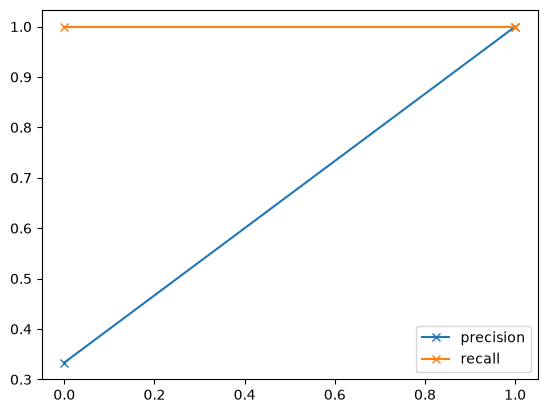

In [111]:
from sklearn.metrics import precision_recall_curve

y_train_is1 = y_train == 0  # True for the first class.
y_score_c1 = y_score[:, 0]  # scores for the first class.

precision, recall, thresholds = precision_recall_curve(y_train_is1, y_score_c1)

plt.plot(thresholds, precision[:-1], '-x', label='precision')
plt.plot(thresholds, recall[:-1], '-x', label='recall')
plt.legend()

### ROC Curve

> Note) `roc_curve` does not support multi-class.

auc=1.0000


Text(0, 0.5, 'tpr (TP/P)')

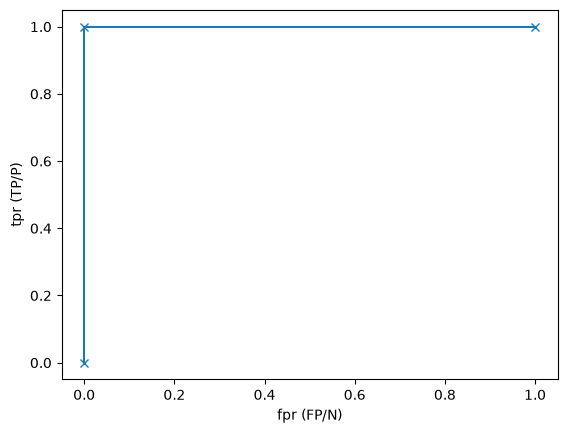

In [126]:
from sklearn.metrics import roc_curve, roc_auc_score

# Does not support multi-class.
y_train_is1 = y_train == 0  # True for the first class.
y_score_c1 = y_score[:, 0]  # scores for the first class.

fpr, tpr, thresholds = roc_curve(y_train_is1, y_score_c1)
auc = roc_auc_score(y_train_is1, y_score_c1)

print(f"auc={auc:.4f}")

plt.plot(fpr, tpr, '-x')
plt.xlabel('fpr (FP/N)')
plt.ylabel('tpr (TP/P)')

# 4. Regression

## 1) Summary

| Metric | Formula | scikit-learn |
|---|---|---|
| MAE | $\mathrm{MAE}=\frac{1}{M}\sum_{i=1}^{M}\lvert y_i-\hat{y}_i\rvert$ | `mean_absolute_error` |
| MSE | $\mathrm{MSE}=\frac{1}{M}\sum_{i=1}^{M}(y_i-\hat{y}_i)^2$ | `mean_squared_error` |
| RMSE | $\mathrm{RMSE}=\sqrt{\frac{1}{M}\sum_{i=1}^{M}(y_i-\hat{y}_i)^2}=\sqrt{\mathrm{MSE}}$ | `root_mean_squared_error` |
| $R^2$ (Coefficient of Determination) | $R^2=1-\frac{\sum_{i=1}^{M}(y_i-\hat{y}_i)^2}{\sum_{i=1}^{M}(y_i-\bar{y})^2}$<br>$\bar{y}=\frac{1}{M}\sum_{i=1}^{M}y_i$ | `r2_score` |
| MAPE | $\mathrm{MAPE}=\frac{1}{M}\sum_{i=1}^{M}\left\lvert\frac{y_i-\hat{y}_i}{y_i}\right\rvert$ | `mean_absolute_percentage_error` |

## 2) Example

### Data

In [128]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

X, y = fetch_california_housing(
    return_X_y=True,
    as_frame=True,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=True,
    random_state=seed,
)

### Prediction

In [137]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_predict

estimator = DecisionTreeRegressor()

y_pred = cross_val_predict(
    estimator=estimator,
    X=X_train,
    y=y_train,
    cv=5,
)

### Scores

In [138]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

mean_absolute_error(y_train, y_pred)
mean_squared_error(y_train, y_pred)
root_mean_squared_error(y_train, y_pred)
r2_score(y_train, y_pred)
mean_absolute_percentage_error(y_train, y_pred)

0.2536847356014955

# 5. Clustering

- Inertia, $I = \displaystyle\sum_{k=1}^{K}\displaystyle\sum_{i:y_i=k}\|x_i-C_k\|^2$
- Silhouette score, $s_i = \frac{b_i-a_i}{\max(a_i,b_i)}$
- ARI, Adjusted Rand Index
  - $RI = \frac{n\_correct\_pairs}{n\_pairs}$
  - $ARI = \frac{RI - E[RI]}{1 - E[RI]}$, where $E[RI] = pr(\text{both in same cluster}) + pr(\text{both in diff cluster})$
- NMI, Normalized Mutual Information
  - How much knowing the predicted cluster is informative to know the real cluster?
  - $NMI(U,V) = \frac{2MI(U,V)}{H(U)+H(V)}$
- Stability accross repetition
- Domain rules: cluster size/deviation, etc.

In [148]:
from itertools import combinations
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

# Data
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    random_state=42,
)

# Model
model = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=seed,
)

# Prediction
y_pred = model.fit_predict(X)

# Metrics
model.inertia_
silhouette_score(X, y_pred)
adjusted_rand_score(y_true, y_pred)
normalized_mutual_info_score(y_true, y_pred)

# Stability
runs = [
    KMeans(n_clusters=3, n_init=10, random_state=i).fit_predict(X)
    for i in range(5)
]
stability = np.mean([
    adjusted_rand_score(a, b)
    for a, b in combinations(runs, 2)
])

# Cluster size
cluster_sizes = np.bincount(y_pred)

# Cluster deviation
cluster_deviation = np.array([
    np.mean(np.linalg.norm(
        X[y_pred == k] - model.cluster_centers_[k],
        axis=1,
    ))
    for k in range(model.n_clusters)
])